# Aprendizaje Automático con Python
# Equipo 5


### 14 de Mayo del 2026
### TI3002C
### ITESM
### a01753363@tec.mx


## Entrenando Modelos de Árboles de Decisión y Random Forest en Python

En este notebook, exploraremos cómo entrenar y evaluar modelos de **Árboles de Decisión** y **Random Forest** utilizando Python y la biblioteca `scikit-learn`. Estos algoritmos son muy populares y poderosos para tareas de clasificación. Trabajaremos con un conjunto de datos sintético proporcionado por Liverpool, el cual contiene información sobre marcas, ventas y otras métricas.

El objetivo principal es predecir si una marca **"Renovó"** su registro (nuestra variable objetivo) basándonos en las demás características del dataset.

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

### Carga y Exploración de Datos
Comenzaremos cargando una muestra del dataset provisto y explorando sus características básicas para entender con qué estamos trabajando.

In [ ]:
df = pd.read_excel("procesamiento_final.xlsx")
# Mostrar las primeras filas del dataset
display(df.head())

,DENOMINACIÓN,Descripción,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),Avg Market Share,Crecimiento Total Sales
0,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",335.125000,7.340517e+04,7,52.250000,3.254327,56.750000,si,0.001140,0.001137,-0.017314
1,#OCTUBREROSA CUIDATE,PUBLICIDAD; GESTION DE NEGOCIOS COMERCIALES; A...,321.875000,9.277497e+04,7,63.000000,3.198713,51.750000,si,0.001505,0.001479,-0.128812
2,#ZONA D,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",172.000000,7.223436e+04,11,29.272727,2.327540,30.272727,no,0.001579,0.001627,-0.373398
3,#ZONA D,"PUBLICIDAD, GESTION DE NEGOCIOS COMERCIALES, A...",430.090909,7.795504e+04,11,68.000000,2.318617,76.818182,no,0.001645,0.001705,-0.333679
4,1 TO 9,"VESTUARIO CASUAL, INFORMAL, DE GALA, DEPORTIVO...",59238.466667,7.772100e+06,29,23615.400000,4.296330,3036.300000,si,0.157607,0.159221,0.224401


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   DENOMINACIÓN                        2764 non-null   object 
 1   Descripción                         2764 non-null   object 
 2   Total Sales                         2764 non-null   float64
 3   Revenue                             2764 non-null   float64
 4   Antigüedad de la Marca              2764 non-null   int64  
 5   Número de Leads en Web              2764 non-null   float64
 6   Calificación Promedio de Productos  2764 non-null   float64
 7   Número de Devoluciones              2764 non-null   float64
 8   Renovó                              2764 non-null   object 
 9   Participación de Mercado (%)        2764 non-null   float64
 10  Avg Market Share                    2764 non-null   float64
 11  Crecimiento Total Sales             2764 no

### Preprocesamiento de Datos
Antes de entrenar los modelos necesitamos:
1. Seleccionar las características principales (*features*) y lo que queremos predecir (*target*).
2. Convertir los valores de texto de la columna a predecir (`si`/`no`) en valores binarios (`1`/`0`).
3. Dividir el conjunto total en un grupo de **entrenamiento** (para que los modelos aprendan) y otro grupo de **prueba** (para medir qué tan bien aprendieron).

In [ ]:
# 1. Separar características (X) y la variable objetivo (y)
features = ['Total Sales', 'Revenue', 'Antigüedad de la Marca', 'Número de Leads en Web', 'Calificación Promedio de Productos', 'Número de Devoluciones','Crecimiento Total Sales']
target = 'Renovó'

X = df[features]
y = df[target]

# 2. Mapear la variable objetivo a valores numéricos (si=1, no=0)
y = y.map({'si': 1, 'no': 0})

# 3. Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (1934, 7)
Tamaño del conjunto de prueba (X_test): (830, 7)


### Modelo 1: Árbol de Decisión
Un árbol de decisión es un modelo predictivo que toma decisiones basándose en una serie de preguntas condicionales sobre los datos. Es fácil de entender e interpretar, pero puede sufrir de *overfitting* (sobreajuste), lo que significa que memoriza los datos de entrenamiento pero se equivoca con datos nuevos.

In [ ]:
# Inicializar y entrenar el modelo de Árbol de Decisión
decision_tree_model = DecisionTreeClassifier(random_state=3002)
decision_tree_model.fit(X_train, y_train)

# Realizar predicciones usando los datos reservados para prueba
y_pred_dt = decision_tree_model.predict(X_test)

#### Evaluación del Árbol de Decisión
Generamos un reporte con métricas clave y una Matriz de Confusión para visualizar en qué clases acierta y en cuáles se equivoca.

--- Métricas de Árbol de Decisión ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       229
           1       0.99      0.99      0.99       601

    accuracy                           0.98       830
   macro avg       0.98      0.98      0.98       830
weighted avg       0.98      0.98      0.98       830

Especificidad: 0.98


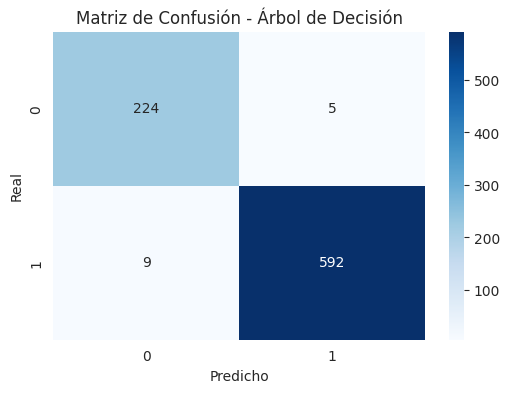

In [ ]:
print("--- Métricas de Árbol de Decisión ---")
print(classification_report(y_test, y_pred_dt))

# Cálculo de Especificidad
cm_dt = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm_dt.ravel()
specificity_dt = tn / (tn + fp)
print(f"Especificidad: {specificity_dt:.2f}")

# Creación de la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Visualización Avanzada del Árbol de Decisión con Graphviz

Para una visualización aún más detallada y personalizable del árbol de decisión, podemos utilizar la librería `graphviz`. Esto nos permite generar un gráfico interactivo o de mayor calidad que `plot_tree` de `scikit-learn`.

In [ ]:
# Instalar graphviz si no está instalado
!pip install graphviz

import graphviz
from sklearn.tree import export_graphviz

# Exportar el árbol a un archivo DOT
dot_data = export_graphviz(decision_tree_model,
                           feature_names=features,
                           class_names=['No Renovó', 'Renovó'],
                           filled=True, rounded=True,
                           special_characters=True,
                           proportion=True,
                           out_file=None)

# Renderizar el gráfico
graph = graphviz.Source(dot_data)

# Guardar y mostrar el gráfico
graph.render("decision_tree_graphviz", format='png', view=True)
print("Gráfico del árbol de decisión generado y guardado como 'decision_tree_graphviz.png'. Se abrirá automáticamente.")


Gráfico del árbol de decisión generado y guardado como 'decision_tree_graphviz.png'. Se abrirá automáticamente.


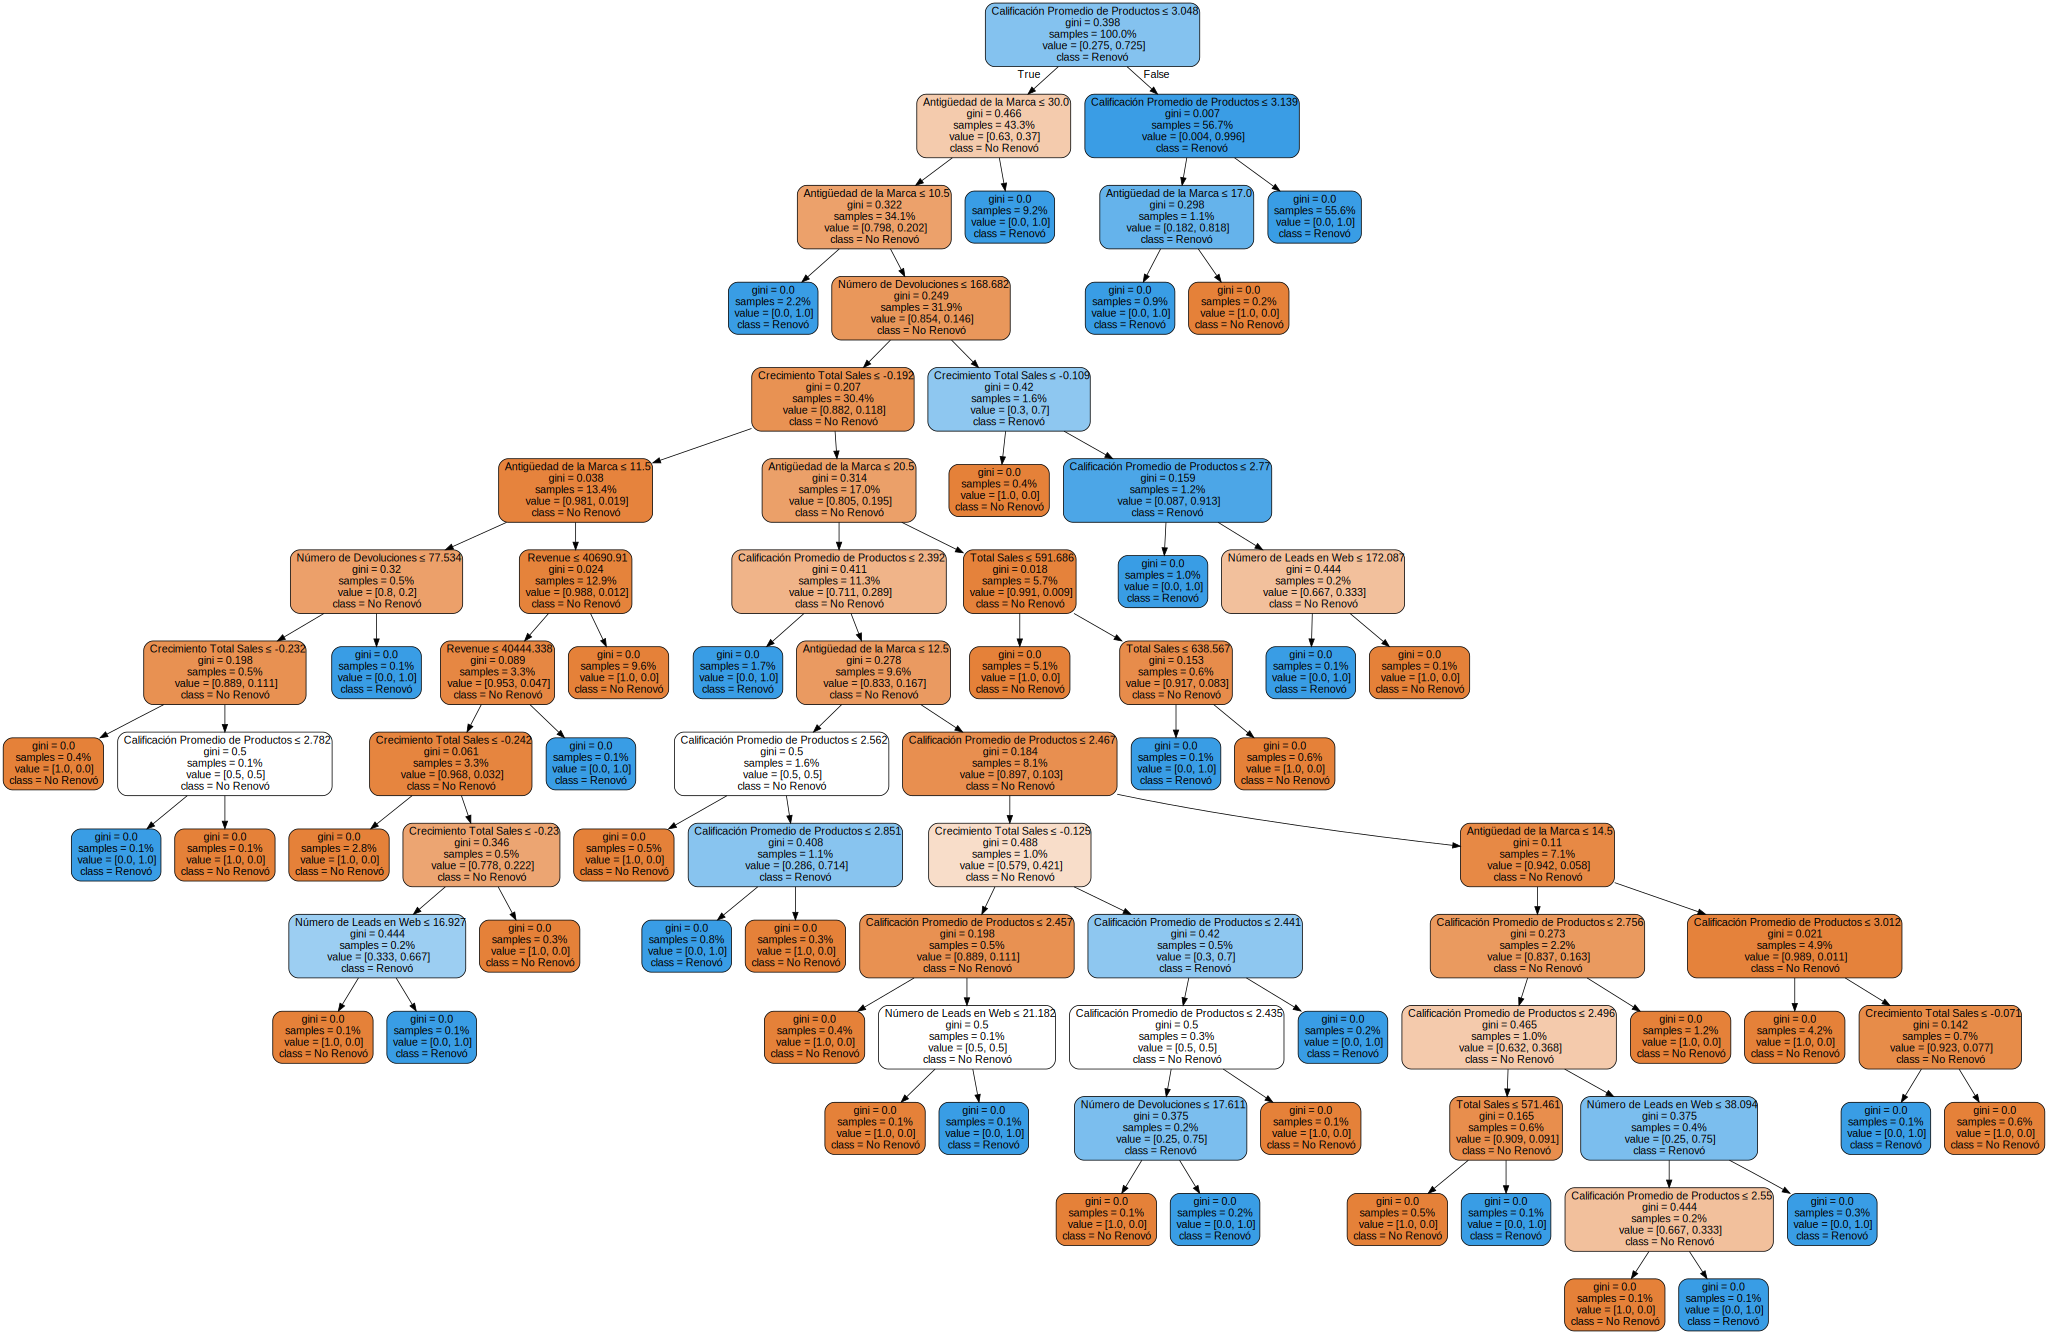

In [ ]:
# Para mostrar el gráfico directamente en el notebook (opcional si ya se abrió con view=True)
graph

El archivo `decision_tree_graphviz.png` ha sido generado y debería abrirse automáticamente en su navegador o visor de imágenes predeterminado. También puedes ver el renderizado del gráfico directamente aquí.

### Persistencia del Modelo
Para evitar reentrenar el modelo cada vez que necesitemos usarlo, podemos guardarlo en un archivo utilizando la biblioteca `joblib`. Esto permite exportar el modelo entrenado y cargarlo posteriormente en este o en otros entornos.

In [ ]:
y_pred = decision_tree_model.predict(df[features][0:3])

In [ ]:
import joblib

# Guardar el modelo Árbol de decisinoes
filename = 'decision_tree_model.joblib'
joblib.dump(decision_tree_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

Modelo 'decision_tree_model.joblib' guardado exitosamente.


In [ ]:
import joblib

# Guardar el modelo Árbol de decisiones
filename = 'decision_tree_model.joblib'
joblib.dump(decision_tree_model, filename)
print(f"Modelo '{filename}' guardado exitosamente.")

# Cargar el modelo guardado
loaded_model = joblib.load(filename)
print(f"Modelo '{filename}' cargado exitosamente.")

# Demostrar que el modelo cargado puede hacer predicciones
y_pred_loaded = loaded_model.predict(df[features][0:3])
print("\nPredicciones con el modelo cargado (Random Forest):")
print(y_pred_loaded)

# Comparar con las predicciones originales del modelo Random Forest
import numpy as np
print("¿Las predicciones del modelo cargado son idénticas a las originales?", np.array_equal(y_pred, y_pred_loaded))

Modelo 'decision_tree_model.joblib' guardado exitosamente.
Modelo 'decision_tree_model.joblib' cargado exitosamente.

Predicciones con el modelo cargado (Random Forest):
[1 1 0]
¿Las predicciones del modelo cargado son idénticas a las originales? True


## Guardar el modelo en excel


In [ ]:
import pandas as pd
import joblib

# Cargar modelo entrenado
loaded_model = joblib.load("decision_tree_model.joblib")

# Cargar archivo original
df_original = pd.read_excel("procesamiento_final.xlsx")

# Variables que usa el modelo
X = df_original[features]

# Predicciones
predicciones = loaded_model.predict(X)

# Agregar columna al archivo original
df_original["Renovacion_Predicha"] = predicciones

# Convertir 0 y 1 a texto
df_original["Renovacion_Predicha"] = df_original["Renovacion_Predicha"].map({
    1: "Se recomienda renovar",
    0: "No se recomienda renovar"
})

# Guardar archivo final
df_original.to_excel(
    "Procesamiento_final_predicciones.xlsx",
    index=False
)

print("Archivo generado correctamente")

Archivo generado correctamente


### Pruebas de Predicción
Una vez que el modelo está cargado, es importante validar que funciona correctamente realizando predicciones con datos nuevos o específicos.

#### 1. Predicción Individual (1 a 1)
En este escenario, simulamos la entrada de un solo registro manual para observar la respuesta del modelo en tiempo real.

In [ ]:
# 1 a 1

registro_marca = {'Total Sales': 50.0, 'Revenue': 8791.078577753173, 'Antigüedad de la Marca': 9.0, 'Número de Leads en Web': 18.0, 'Calificación Promedio de Productos': 7.02900644475073, 'Número de Devoluciones': 5.0,'Crecimiento Total Sales':0.8}
predicción = loaded_model.predict(np.array(list(registro_marca.values())).reshape(1, -1))
print(registro_marca)
print(predicción)


NameError: name 'loaded_model' is not defined

#### 2. Predicción en Lote (Batch)
Finalmente, cargamos un archivo de Excel con múltiples registros, aplicamos la limpieza necesaria para que coincida con las características (*features*) del entrenamiento y realizamos predicciones masivas.

In [ ]:
# Batch Data
batch_data_df = pd.read_excel("batch_data.xlsx")

X_batch = batch_data_df[features]

predicciones_batch = loaded_model.predict(X_batch)

batch_data_df["prediccion"] = predicciones_batch

batch_data_df.head(20)

,DENOMINACIÓN,Descripción,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),Avg Market Share,Crecimiento Total Sales,prediccion
0,Equipo 5 S.A. de C.V.,SERVICIOS DE MARKETING Y PUBLICIDAD,49707.98,1076735.57,34,11344.15,3.259785,3233.35,no,0.134264,0.193892,0.138115,1
1,Los Contebrios de Erick S.A. de C.V.,"LOGÍSTICA, TRANSPORTE Y DISTRIBUCIÓN",63162.05,9932890.89,31,23317.31,3.965087,3879.42,no,0.001606,0.131246,-0.101877,1
2,Consultoría Tec Rosa S.A. de C.V.,SERVICIOS DE CONSULTORÍA EMPRESARIAL Y FINANCIERA,68368.33,8236765.97,6,19689.66,4.560461,2559.40,si,0.186962,0.019522,0.208512,1
3,Innovaciones Boreal S.A.P.I. de C.V.,DESARROLLO DE SOFTWARE Y SOLUCIONES TECNOLÓGICAS,76054.70,91792.62,33,10713.48,2.575538,54.54,no,0.098068,0.083911,0.106281,1
4,Grupo Jaguar Financiero S.A. de C.V.,"LOGÍSTICA, TRANSPORTE Y DISTRIBUCIÓN",54052.59,11192898.89,29,20787.09,2.162944,418.16,si,0.181199,0.148444,0.299648,1
5,Erickcito pelón S.A. de C.V.,SERVICIOS DE MARKETING Y PUBLICIDAD,14334.54,11572375.68,9,6680.70,2.832976,3972.27,si,0.047749,0.138655,0.024572,1
6,GOOOOYA de Suburbia S.A. de C.V.,"LOGÍSTICA, TRANSPORTE Y DISTRIBUCIÓN",39234.40,3642631.04,34,17192.32,2.547826,246.12,no,0.015470,0.129910,0.356889,1
7,Titanium Logistics S.A. de C.V.,"LOGÍSTICA, TRANSPORTE Y DISTRIBUCIÓN",70889.63,6639883.10,8,21049.91,4.646973,113.40,si,0.137960,0.190934,-0.204007,1
8,FIFF 2026 S.A.P.I.,COMERCIALIZACIÓN DE ALIMENTOS Y BEBIDAS,47893.10,8698881.54,30,28090.31,3.191594,1919.08,si,0.130860,0.027622,0.150599,1
9,Vibrart de Karla tercero S.A. de C.V.,"LOGÍSTICA, TRANSPORTE Y DISTRIBUCIÓN",38191.01,1972582.28,19,7634.69,3.987996,681.18,no,0.174453,0.092017,-0.098615,1


In [ ]:
batch_data_df.to_excel("predicciones_resultado.xlsx", index=False)

from google.colab import files
files.download("predicciones_resultado.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>